Expand Satellite View Dataset - using data augmentation and data preprocessing

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
#Unzip the dataset - Satellite dataset
import zipfile, os

zip_path = "/content/satellite_dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['.config', 'bare_lands', '.ipynb_checkpoints', 'satellite_dataset_expanded', 'satellite_dataset', 'buildings', 'satellite_dataset.zip', 'vegetations', 'satellite_dataset_expanded.zip', 'sample_data']


In [ ]:
#Check classes in my dataset - Satellite dataset
data_dir = "/content/satellite_dataset"

print(os.listdir(data_dir)) #classes

for cls in os.listdir(data_dir):
    print(cls, ":", len(os.listdir(os.path.join(data_dir, cls))), "images")

['bare_lands', 'buildings', 'vegetations']
bare_lands : 200 images
buildings : 200 images
vegetations : 200 images


In [ ]:
#New folder for the expanded dataset - Satellite dataset
import os

base_dir = "/content/satellite_dataset"
expanded_dir = "/content/satellite_dataset_expanded"

classes = ["bare_lands", "buildings", "vegetations"]

os.makedirs(expanded_dir, exist_ok=True)
for cls in classes:
  os.makedirs(os.path.join(expanded_dir, cls), exist_ok=True)

print("Expanded Folders Created:")
print(os.listdir)

Expanded Folders Created:
['bare_lands', 'buildings', 'vegetations']


In [ ]:
#Copy original images into expanded dataset - Satellite dataset
#Original images and augmented images are together

import shutil

for cls in classes:
  src = os.path.join(base_dir, cls)
  dst = os.path.join(expanded_dir, cls)
  for fname in os.listdir(src):
    src_path = os.path.join(src, fname)
    dst_path = os.path.join(dst, fname)
    shutil.copy(src_path, dst_path)

for cls in classes:
  print(cls, "now has", len(os.listdir(os.path.join(expanded_dir, cls))), "images (original only)")

bare_lands now has 200 images (original only)
buildings now has 200 images (original only)
vegetations now has 200 images (original only)


In [ ]:
#Define data augmentation settings - Satellite dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

datagen = ImageDataGenerator(
    rotation_range=30,           #rotate up to 30°
    width_shift_range=0.1,       #shift left/right by 10%
    height_shift_range=0.1,      #shift up/down by 10%
    zoom_range=0.1,              #zoom in/out by 10%
    horizontal_flip=True,        #flip left-right
    vertical_flip=True,          #flip up-down
    brightness_range=[0.8, 1.2], #slightly darekr/brighter
)

In [ ]:
#Generate more images per class with random transformations - Satellite dataset
import numpy as np

num_new_per_image = 2

for cls in classes:
  src_folder = os.path.join(base_dir, cls)
  save_folder = os.path.join(expanded_dir, cls)

  image_files = [f for f in os.listdir(src_folder)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))]

  print(f"\nClass: {cls}")
  print("Original images:", len(image_files))

  for fname in image_files:
    img_path = os.path.join(src_folder, fname)

    #Load image
    img = load_img(img_path)     #Original size kept
    x = img_to_array(img)         #to numpy array
    x = np.expand_dims(x, axis=0) #shape (1, h, w, 3)

    #Create generator for this single image
    aug_iter = datagen.flow(
        x,
        batch_size=1,
        save_to_dir=save_folder,
        save_prefix=cls,
        save_format='png'
    )

    #Actually generate and save images
    for i in range(num_new_per_image):
      next(aug_iter)    #Each call saves 1 new file in save_folder

  #Show count after finishing this class
  total = len(os.listdir(save_folder))
  print("Total images (original + augmented) now in", cls, ":", total)


Class: bare_lands
Original images: 200
Total images (original + augmented) now in bare_lands : 596

Class: buildings
Original images: 200
Total images (original + augmented) now in buildings : 589

Class: vegetations
Original images: 200
Total images (original + augmented) now in vegetations : 592


In [ ]:
#Zip the expanded folder in colab - Satellite dataset
!zip -r /content/satellite_dataset_expanded.zip /content/satellite_dataset_expanded

  adding: content/satellite_dataset_expanded/ (stored 0%)
  adding: content/satellite_dataset_expanded/bare_lands/ (stored 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_6482.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_5299.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_8076.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_2487.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_4518.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_9036.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_6728.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_land82.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_lands/bare_lands_0_695.png (deflated 0%)
  adding: content/satellite_dataset_expanded/bare_la

Expand Street View Dataset - using data augmentation and data preprocessing

In [ ]:
#Unzip the dataset - street view dataset
import os, zipfile

zip_path = "/content/street_view_dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_path)

print(os.listdir(extract_path))

['.config', 'street_view_dataset', 'street_view_dataset.zip', '.ipynb_checkpoints', 'sample_data']


In [ ]:
#Check classes in my dataset - Street view dataset
data_dir = "/content/street_view_dataset"

print(os.listdir(data_dir)) #classes

for cls in os.listdir(data_dir):
    print(cls, ":", len(os.listdir(os.path.join(data_dir, cls))), "images")

['boundary_wall_gates', 'vegetation', 'building_front']
boundary_wall_gates : 200 images
vegetation : 200 images
building_front : 200 images


In [ ]:
#Check how many images currently have - Street view dataset

import os

base_dir = "street_view_dataset"
classes = ["boundary_wall_gates", "building_front", "vegetation"]

def count_images(folder):
  exts = (".jpg", ".jpeg", ".png", ".webp")
  return len([f for f in os.listdir(folder) if f.lower().endswith(exts)])

for c in classes:
  path = os.path.join(base_dir, c)
  print(c, "=>", count_images(path))

boundary_wall_gates => 200
building_front => 200
vegetation => 200


In [ ]:
#Install augmentation library
!pip -q install albumentations opencv-python-headless

In [ ]:
#Create new folder for expanded dataset - street view dataset
import os
expanded_dir = "street_view_dataset_expanded"
os.makedirs(expanded_dir, exist_ok=True)

for c in ["boundary_wall_gates", "building_front", "vegetation"]:
  os.makedirs(os.path.join(expanded_dir, c), exist_ok=True)

print("Created", expanded_dir)

Created street_view_dataset_expanded


In [ ]:
#Copy original images first - street view dataset
import shutil, os

base_dir = "street_view_dataset"
expanded_dir = "street_view_dataset_expanded"
exts = (".jpg", ".jpeg", ".png", ".webp")

for c in ["boundary_wall_gates", "building_front", "vegetation"]:
  src = os.path.join(base_dir, c)
  dst = os.path.join(expanded_dir, c)

  for f in os.listdir(src):
    if f.lower().endswith(exts):
      shutil.copy2(os.path.join(src, f), os.path.join(dst, f))

print("Original images copied to the expanded folder")

Original images copied to the expanded folder


In [ ]:
#Expand each class into more images - street view dataset
import os, random
import cv2
import albumentations as A

base_dir = "street_view_dataset"
expanded_dir = "street_view_dataset_expanded"

classes = ["boundary_wall_gates", "building_front", "vegetation"]
TARGET = 600
exts = (".jpg", ".jpeg", ".png", ".webp")

aug = A.Compose([
    A.RandomBrightnessContrast(p=0.7),
    A.HueSaturationValue(p=0.4),
    A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.6),
    A.RandomScale(scale_limit=0.1, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.1, rotate_limit=0, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.2),
])

def list_images(folder):
  return [f for f in os.listdir(folder) if f.lower().endswith(exts)]

def safe_read(path):
  img = cv2.imread(path)
  return img

for c in classes:
  src_folder = os.path.join(base_dir, c)
  out_folder = os.path.join(expanded_dir, c)

  src_imgs = list_images(src_folder)
  if len(src_imgs) == 0:
    print(f"No images found in {c}. Skipping.")
    continue

  current = len(list_images(out_folder))
  need = TARGET - current

  print(f"\nClass: {c}")
  print("Current:", current, "| Target:", TARGET, "| Need more:", max(0, need))

  i = 0
  while len(list_images(out_folder)) < TARGET:
    pick = random.choice(src_imgs)
    img_path = os.path.join(src_folder, pick)

    img = safe_read(img_path)
    if img is None:
      continue

    out = aug(image=img)["image"]

    new_name = f"aug_{c}_{i:05d}.jpg"
    cv2.imwrite(os.path.join(out_folder, new_name), out)
    i += 1

  print(f"Done: {c} now has {len(list_images(out_folder))} images")


Class: boundary_wall_gates
Current: 600 | Target: 600 | Need more: 0
Done: boundary_wall_gates now has 600 images

Class: building_front
Current: 600 | Target: 600 | Need more: 0
Done: building_front now has 600 images

Class: vegetation
Current: 600 | Target: 600 | Need more: 0
Done: vegetation now has 600 images


/tmp/ipython-input-2721468966.py:20: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 40.0), p=0.2),


In [ ]:
#Verify final number of images - street view dataset
import os

expanded_dir = "street_view_dataset_expanded"
classes = ["boundary_wall_gates", "building_front", "vegetation"]
exts = (".jpg", ".jpeg", ".png", ".webp")

def count_images(folder):
  return len([f for f in os.listdir(folder) if f.lower().endswith(exts)])

print("Final counts:")
total = 0
for c in classes:
  n = count_images(os.path.join(expanded_dir, c))
  total += n
  print(c, "=>", n)

print("TOTAL =>", total)

Final counts:
boundary_wall_gates => 600
building_front => 600
vegetation => 600
TOTAL => 1800



Class: boundary_wall_gates


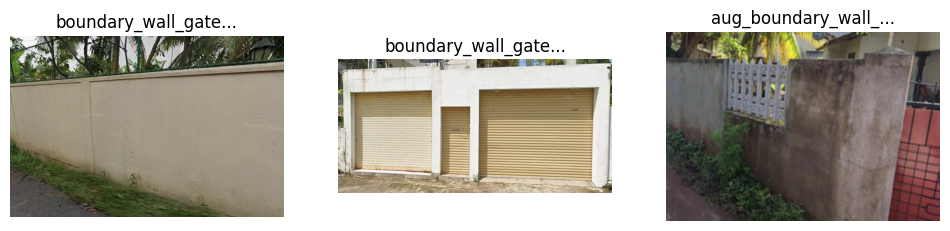


Class: building_front


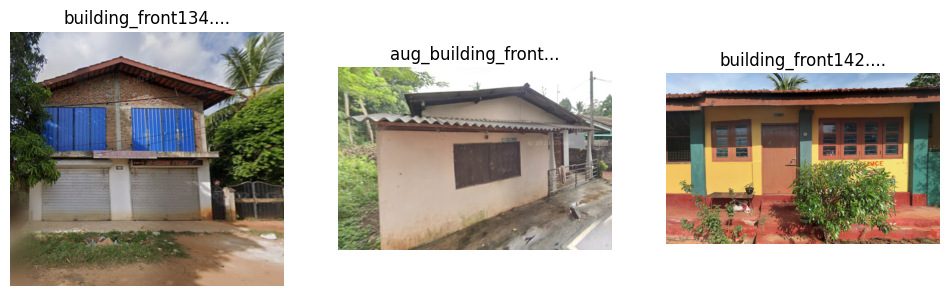


Class: vegetation


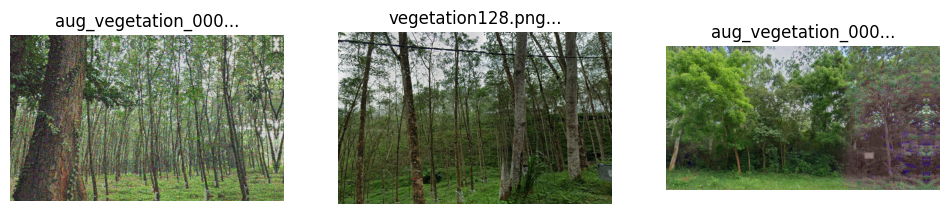

In [ ]:
#Preview three images per class
import matplotlib.pyplot as plt
import cv2, os, random

expanded_dir = "street_view_dataset_expanded"
classes = ["boundary_wall_gates", "building_front", "vegetation"]
exts = (".jpg", ".jpeg", ".png", ".webp")

for c in classes:
  folder = os.path.join(expanded_dir, c)
  imgs = [f for f in os.listdir(folder) if f.lower().endswith(exts)]
  picks = random.sample(imgs, 3)

  print("\nClass:", c)
  plt.figure(figsize=(12,4))
  for i, p in enumerate(picks):
    img = cv2.imread(os.path.join(folder, p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(p[:18]+"...")
  plt.show()

In [ ]:
#Zip the expanded dataset to download - street view dataset
import shutil

zip_name = "street_view_dataset_expanded.zip"
shutil.make_archive("street_view_dataset_expanded", "zip", "street_view_dataset_expanded")

print("Created:", zip_name)

Created: street_view_dataset_expanded.zip


Satellite Dataset - Image resizing 128 * 128

In [ ]:
!ls

sample_data  satellite_dataset_expanded.zip


In [ ]:
!unzip /content/satellite_dataset_expanded.zip

Archive:  /content/satellite_dataset_expanded.zip
   creating: content/satellite_dataset_expanded/
   creating: content/satellite_dataset_expanded/bare_lands/
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_6482.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_5299.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_8076.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_2487.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_4518.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_9036.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_6728.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_land82.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_695.png  
  inflating: content/satellite_dataset_expanded/bare_lands/bare_lands_0_4745.png  
  inflating: conte

In [ ]:
!ls /content/content/satellite_dataset_expanded

bare_lands  buildings  vegetations


In [ ]:
!pip install pillow #Pillow library is used for image resizing

In [ ]:
import os

INPUT_DIR = "/content/content/satellite_dataset_expanded"
OUTPUT_DIR = "satellite_dataset_128"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
#Resize all images to 128 * 128
from PIL import Image
import os

IMAGE_SIZE = (128, 128)

for class_name in os.listdir(INPUT_DIR):
  class_input_path = os.path.join(INPUT_DIR, class_name)
  class_output_path = os.path.join(OUTPUT_DIR, class_name)

  if not os.path.isdir(class_input_path):
    continue

  os.makedirs(class_output_path, exist_ok=True)

  for img_name in os.listdir(class_input_path):
    img_path = os.path.join(class_input_path, img_name)
    output_img_path = os.path.join(class_output_path, img_name)

    try:
      img = Image.open(img_path).convert("RGB")
      img = img.resize(IMAGE_SIZE)
      img.save(output_img_path)
    except Exception as e:
      print(f"Error processing {img_path}: {e}")

print("All images resized to 128x128 successfully!")

All images resized to 128x128 successfully!


In [ ]:
#Verify resized images
!ls satellite_dataset_128

bare_lands  buildings  vegetations


In [ ]:
#Verify resized images - number of images
!ls satellite_dataset_128/buildings | wc -l

589


In [ ]:
#Zip resized satellite_view_dataset
!zip -r satellite_dataset_128.zip satellite_dataset_128

  adding: satellite_dataset_128/ (stored 0%)
  adding: satellite_dataset_128/bare_lands/ (stored 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_1378.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_land115.png (stored 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_9184.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_1843.png (stored 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_3502.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_9757.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_land73.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_land38.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_9243.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_9468.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_land51.png (deflated 0%)
  adding: satellite_dataset_128/bare_lands/bare_lands_0_3

Split the satellite dataset into train, valid and test
*   70% - Training
*   15% - Validation
*   15% - Testing



In [ ]:
#Unzip the dataset
import zipfile
import os

zip_path = "/content/satellite_dataset_128.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [26]:
#Check the dataset structure
import os

base_dir = "/content/satellite_dataset_128"

for class_name in os.listdir(base_dir):
  class_path = os.path.join(base_dir, class_name)
  if os.path.isdir(class_path):
    print(class_name, "-", len(os.listdir(class_path)), "images")

bare_lands - 596 images
buildings - 589 images
vegetations - 592 images


In [27]:
#Create train/test/valid folder
split_base = "/content/satellite_dataset_new"

splits = ["train", "val", "test"]

for split in splits:
  for class_name in os.listdir(base_dir):
    os.makedirs(os.path.join(split_base, split, class_name), exist_ok=True)

print("Train/Test/Valid folder structure created")

Train/Test/Valid folder structure created


In [28]:
import random
import shutil

In [29]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

In [30]:
#Split images class by class
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Ensure the target directories exist before copying
    os.makedirs(os.path.join(split_base, "train", class_name), exist_ok=True)
    os.makedirs(os.path.join(split_base, "val", class_name), exist_ok=True)
    os.makedirs(os.path.join(split_base, "test", class_name), exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(split_base, "train", class_name, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(split_base, "val", class_name, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(split_base, "test", class_name, img)
        )

    print(f"{class_name}: Train={len(train_images)}, Val={len(val_images)}, Test={len(test_images)}")

bare_lands: Train=417, Val=89, Test=90
buildings: Train=412, Val=88, Test=89
vegetations: Train=414, Val=88, Test=90


In [31]:
#Verify final split counts
for split in ["train", "val", "test"]:
  print(f"\n{split.upper()}")
  for class_name in os.listdir(os.path.join(split_base, split)):
    count = len(os.listdir(os.path.join(split_base, split, class_name)))
    print(class_name, "-", count)


TRAIN
bare_lands - 417
buildings - 412
vegetations - 414

VAL
bare_lands - 89
buildings - 88
vegetations - 88

TEST
bare_lands - 90
buildings - 89
vegetations - 90


In [32]:
#Zip the dataset
shutil.make_archive(
    "/content/satellite_dataset_new", 'zip', split_base
)

'/content/satellite_dataset_new.zip'

Automatically generate metadata.csv file

In [2]:
#Unzip the dataset
import zipfile

zip_path = "/content/satellite_dataset_new.zip"
extract_path = "/content/satellite_dataset_new"

with zipfile.ZipFile(zip_path, 'r' ) as zip_ref:
  zip_ref.extractall(extract_path)

In [5]:
#Confirm the folder structure
import os

base_dir = "/content/satellite_dataset_new"

for split in ["train", "val", "test"]:
  print(f"Checking {split} folder:")
  for class_name in os.listdir(os.path.join(base_dir, split)):
    class_path = os.path.join(base_dir, split, class_name)
    print(f" {class_name}: {len(os.listdir(class_path))} images")

Checking train folder:
 bare_lands: 417 images
 buildings: 412 images
 vegetations: 414 images
Checking val folder:
 bare_lands: 89 images
 buildings: 88 images
 vegetations: 88 images
Checking test folder:
 bare_lands: 90 images
 buildings: 89 images
 vegetations: 90 images


In [6]:
#Create data.yaml
data_yaml_content = """
train: /content/satellite_dataset_new/train
val: /content/satellite_dataset_new/val
test: /content/satellite_dataset_new/test

number_of_classes: 3
names_of_classes: ['bare_lands', 'buildings', 'vegetations']
"""

with open("/content/satellite_dataset_new/data.yaml", "w") as f:
  f.write(data_yaml_content)

In [18]:
#Create metadata.csv
import pandas as pd
import os
from PIL import Image

data = []  #Initialize the data list

base_path = "/content/satellite_dataset_new"
classes = ["bare_lands", "buildings", "vegetations"]

#Loop through train, test, val splits and each class
for folder in ["train", "val", "test"]:
  for cls_idx, cls in enumerate(classes):
    class_path = os.path.join(base_path, folder, cls)

    #Sorted images alphabetically
    img_names = sorted(os.listdir(class_path))
    #Loop through each image in the class folder
    for img_name in img_names:
      img_path = os.path.join(class_path, img_name)

      #Open image to get height and width
      try:
        img = Image.open(img_path)
        width, height = img.size

        #Append data to the list
        data.append([img_name, img_path, cls, cls_idx, width, height])
      except Exception as e:
        print(f"Error processing {img_path}: {e}")

#Create a DataFrame
metadata_df = pd.DataFrame(data, columns=["image_name", "image_path", "class", "label", "width", "height"])

#Save to CSV file
metadata_df.to_csv("/content/satellite_dataset_new/metadata.csv", index=False)

print("metadata.csv file created.")

metadata.csv file created.


In [19]:
#Zip the dataset folder
import shutil
dataset_folder = "/content/satellite_dataset_new"

zip_name = "/content/satellite_dataset_new.zip"

shutil.make_archive(zip_name.replace(".zip", ""), 'zip', dataset_folder)

'/content/satellite_dataset_new.zip'

Street-View Dataset -Image resizing 128 * 128

In [2]:
!ls

sample_data  street_view_dataset_expanded.zip


In [3]:
#Unzip the dataset
import zipfile
import os

zip_path = "/content/street_view_dataset_expanded.zip"
extract_path = "/content/street_view_dataset_expanded"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

In [4]:
!ls /content/street_view_dataset_expanded

boundary_wall_gates  building_front  vegetation


In [5]:
#Pillow library is used for image resizing
!pip install pillow

In [7]:
#Create new folder for store resized images
import os

INPUT_DIR = "/content/street_view_dataset_expanded"
OUTPUT_DIR = "/content/street_view_dataset_128"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:
#Resize all images to 128 * 128
from PIL import Image
import os

IMAGE_SIZE = (128, 128)

for class_name in os.listdir(INPUT_DIR):
  class_input_path = os.path.join(INPUT_DIR, class_name)
  class_output_path = os.path.join(OUTPUT_DIR, class_name)

  if not os.path.isdir(class_input_path):
    continue

  os.makedirs(class_output_path, exist_ok=True)

  for img_name in os.listdir(class_input_path):
    img_path = os.path.join(class_input_path, img_name)
    output_img_path = os.path.join(class_output_path, img_name)

    try:
      img = Image.open(img_path).convert("RGB")
      img = img.resize(IMAGE_SIZE)
      img.save(output_img_path)
    except Exception as e:
      print(f"Error processing {img_path}: {e}")

print("All images resized to 128x128 successfully!")

All images resized to 128x128 successfully!


In [9]:
#Verify resized images
!ls street_view_dataset_128

#Verify resized images - number of images
!ls street_view_dataset_128/boundary_wall_gates |  wc -l
!ls street_view_dataset_128/building_front | wc -l
!ls street_view_dataset_128/vegetation | wc -l

boundary_wall_gates  building_front  vegetation
600
600
600


In [10]:
#Zip the resized street_view_dataset
!zip -r street_view_dataset_128.zip street_view_dataset_128

  adding: street_view_dataset_128/ (stored 0%)
  adding: street_view_dataset_128/boundary_wall_gates/ (stored 0%)
  adding: street_view_dataset_128/boundary_wall_gates/boundary_wall_gate72.png (deflated 0%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00305.jpg (deflated 3%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00157.jpg (deflated 3%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00042.jpg (deflated 3%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00252.jpg (deflated 3%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00179.jpg (deflated 3%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00391.jpg (deflated 4%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_00012.jpg (deflated 3%)
  adding: street_view_dataset_128/boundary_wall_gates/aug_boundary_wall_gates_0

Split the street view dataset into train, test and valid

*   70% - Training
*   15% - Validation
*   15% - Testing



In [35]:
#Check the dataset structure
import os

base_dir = "/content/street_view_dataset_128"

for class_name in os.listdir(base_dir):
  class_path = os.path.join(base_dir, class_name)
  if os.path.isdir(class_path):
    print(class_name, "-", len(os.listdir(class_path)), "images")

boundary_wall_gates - 600 images
vegetation - 600 images
building_front - 600 images


In [36]:
#Create train/test/valid folder
split_base = "/content/street_view_dataset_new"

splits = ["train", "val", "test"]

for split in splits:
  for class_name in os.listdir(base_dir):
    os.makedirs(os.path.join(split_base, split, class_name), exist_ok=True)

print("Train/Test/Valid folder structure created")

Train/Test/Valid folder structure created


In [37]:
import random
import shutil

In [38]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

In [39]:
#Split images class by class
for class_name in os.listdir(base_dir):
  class_path = os.path.join(base_dir, class_name)
  if not os.path.isdir(class_path):
    continue

  images = os.listdir(class_path)

  random.shuffle(images)

  total = len(images)
  train_end = int(total * train_ratio)
  val_end = train_end + int(total * val_ratio)

  train_images = images[:train_end]
  val_images = images[train_end:val_end]
  test_images = images[val_end:]

  #Ensure the target directories exist before copying
  os.makedirs(os.path.join(split_base, "train", class_name), exist_ok=True)
  os.makedirs(os.path.join(split_base, "val", class_name), exist_ok=True)
  os.makedirs(os.path.join(split_base, "test", class_name), exist_ok=True)

  for img in train_images:
    shutil.copy(
        os.path.join(class_path, img),
        os.path.join(split_base, "train", class_name, img)
    )

  for img in val_images:
    shutil.copy(
        os.path.join(class_path, img),
        os.path.join(split_base, "val", class_name, img)
    )

  for img in test_images:
    shutil.copy(
        os.path.join(class_path, img),
        os.path.join(split_base, "test", class_name, img)
    )

  print(f"{class_name}: Train={len(train_images)}, Val={len(val_images)}, Test={len(test_images)}")

boundary_wall_gates: Train=420, Val=90, Test=90
vegetation: Train=420, Val=90, Test=90
building_front: Train=420, Val=90, Test=90


In [42]:
#Verify final split counts
for split in ["train", "val", "test"]:
  print(f"\n{split.upper()}")
  for class_name in os.listdir(os.path.join(split_base, split)):
    count = len(os.listdir(os.path.join(split_base, split, class_name)))
    print(class_name, "-", count)


TRAIN
boundary_wall_gates - 420
vegetation - 420
building_front - 420

VAL
boundary_wall_gates - 90
vegetation - 90
building_front - 90

TEST
boundary_wall_gates - 90
vegetation - 90
building_front - 90


In [43]:
#Zip the dataset
shutil.make_archive(
    "/content/street_view_dataset_new", 'zip', split_base
)

'/content/street_view_dataset_new.zip'